# Chapter 11: Oil Processing and Stabilization

This notebook demonstrates oil processing concepts using NeqSim:
- Oil stabilization by flash separation at various conditions
- True Vapor Pressure at 37.8 °C (RVP) as a function of stabilizer temperature
- API gravity dependence on processing pressure
- Multi-stage stabilization and gas shrinkage

Oil stabilization removes light components to meet vapor pressure and safety specifications for storage and transport.

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch10_oil_processing_figures.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# NeqSim class imports
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

## Define Oil-Dominant Fluid

We create a crude oil with a range of light-to-heavy components, representative of a medium crude.

In [3]:
def create_oil_fluid(temp_C=80.0, press_bara=50.0):
    """Create a medium crude oil fluid."""
    fluid = SystemSrkEos(273.15 + temp_C, press_bara)
    fluid.addComponent("methane", 0.30)
    fluid.addComponent("ethane", 0.08)
    fluid.addComponent("propane", 0.06)
    fluid.addComponent("i-butane", 0.03)
    fluid.addComponent("n-butane", 0.05)
    fluid.addComponent("i-pentane", 0.04)
    fluid.addComponent("n-pentane", 0.04)
    fluid.addComponent("n-hexane", 0.06)
    fluid.addComponent("n-heptane", 0.08)
    fluid.addComponent("n-octane", 0.10)
    fluid.addComponent("n-nonane", 0.08)
    fluid.addComponent("nC10", 0.08)
    fluid.setMixingRule("classic")
    return fluid

# Quick test
test_fluid = create_oil_fluid()
ops = ThermodynamicOperations(test_fluid)
ops.TPflash()
test_fluid.initProperties()
print(f"Fluid phases: {test_fluid.getNumberOfPhases()}")
print(f"Liquid density: {test_fluid.getPhase('oil').getDensity('kg/m3'):.1f} kg/m3")

Fluid phases: 2
Liquid density: 584.6 kg/m3


## Figure 1: True Vapor Pressure at 37.8 °C vs Stabilizer Temperature

The True Vapor Pressure at 37.8 °C (RVP) is measured at 37.8 °C (100 °F). We stabilize the oil at different temperatures,
separate out the gas, then measure the bubble point pressure of the liquid at 37.8 °C as a proxy for RVP.

TVP range: 0.97 - 2.21 bara


ch10_oil_processing_figures.ipynb:cell6:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


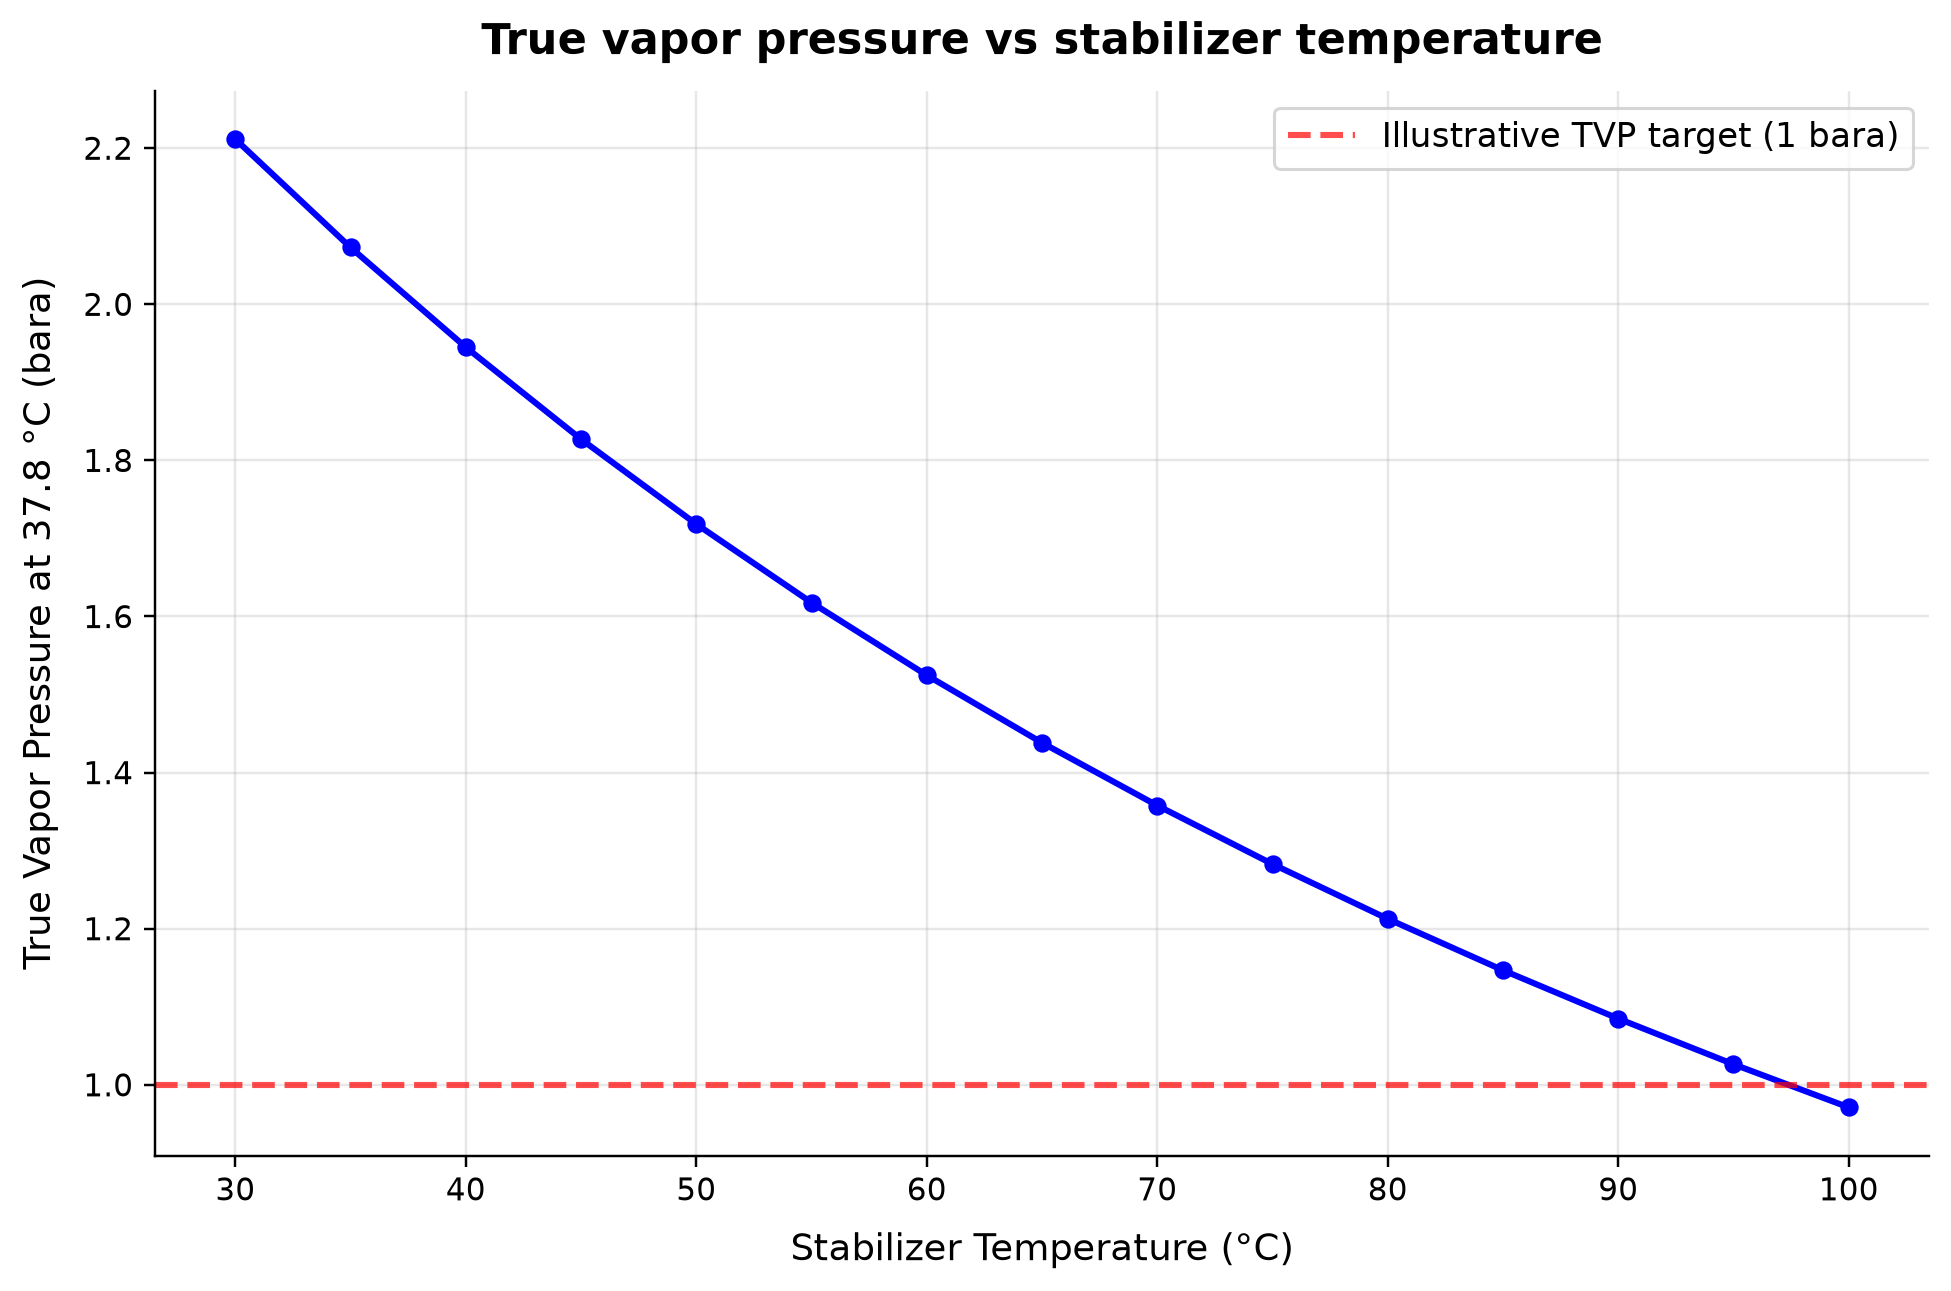

In [4]:
stabilizer_temps_C = np.arange(30, 105, 5)
rvp_values = []
stabilizer_pressure = 2.0  # bara - low pressure stabilizer

for temp_C in stabilizer_temps_C:
    fluid = create_oil_fluid(temp_C=float(temp_C), press_bara=stabilizer_pressure)
    ops = ThermodynamicOperations(fluid)
    ops.TPflash()
    fluid.initProperties()

    # Get liquid phase and calculate bubble pressure at 37.8°C (TVP, not ASTM Reid vapor pressure)
    if fluid.getNumberOfPhases() > 1:
        liquid = fluid.phaseToSystem("oil")
    else:
        liquid = fluid.clone()

    liquid.setTemperature(273.15 + 37.8)
    liquid.setPressure(1.01325)
    ops2 = ThermodynamicOperations(liquid)
    try:
        ops2.bubblePointPressureFlash(False)
        liquid.initProperties()
        bp_pressure = liquid.getPressure("bara")
        rvp_values.append(float(bp_pressure))
    except Exception:
        rvp_values.append(float('nan'))

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(stabilizer_temps_C, rvp_values, 'b-o', linewidth=2, markersize=5)
ax.set_xlabel('Stabilizer Temperature (°C)', fontsize=12)
ax.set_ylabel('True Vapor Pressure at 37.8 °C (bara)', fontsize=12)
ax.set_title('True vapor pressure vs stabilizer temperature', fontsize=14)
ax.grid(True, alpha=0.3)
ax.axhline(y=1.0, color='r', linestyle='--', alpha=0.7, label='Illustrative TVP target (1 bara)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig10_1_rvp_vs_temperature.png', dpi=220, bbox_inches='tight')
plt.show()
print(f"TVP range: {min([v for v in rvp_values if not np.isnan(v)]):.2f} - {max([v for v in rvp_values if not np.isnan(v)]):.2f} bara")

**Executed-figure discussion.** True Vapor Pressure at 37.8 °C spans 0.971–2.212 bara across the plotted cases.

Stabilization heating removes volatile components, changing the equilibrium vapor pressure of the remaining oil at the reporting temperature. This bubble-point-based quantity is TVP; it must not be presented as an ASTM RVP result merely because the calculation uses 37.8°C. Specify the product sampling and vapor-pressure method, then choose duty with a quality margin and a corresponding liquid-recovery calculation.


**Discussion:** Higher stabilizer temperatures drive more light components into the vapor phase, reducing the liquid's vapor pressure. Below ~50 °C, the stabilized oil retains significant light ends and exceeds typical RVP specifications. This shows why heated stabilization columns or multi-stage flash are used in practice.

## Figure 2: Oil API Gravity vs Processing Pressure

API gravity = 141.5 / SG - 131.5, where SG is specific gravity relative to water at 15.6 °C.
We flash the oil at different separator pressures, collect the liquid, then flash again at stock tank conditions.

API range: 68.4 - 69.7 °API


ch10_oil_processing_figures.ipynb:cell9:58: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


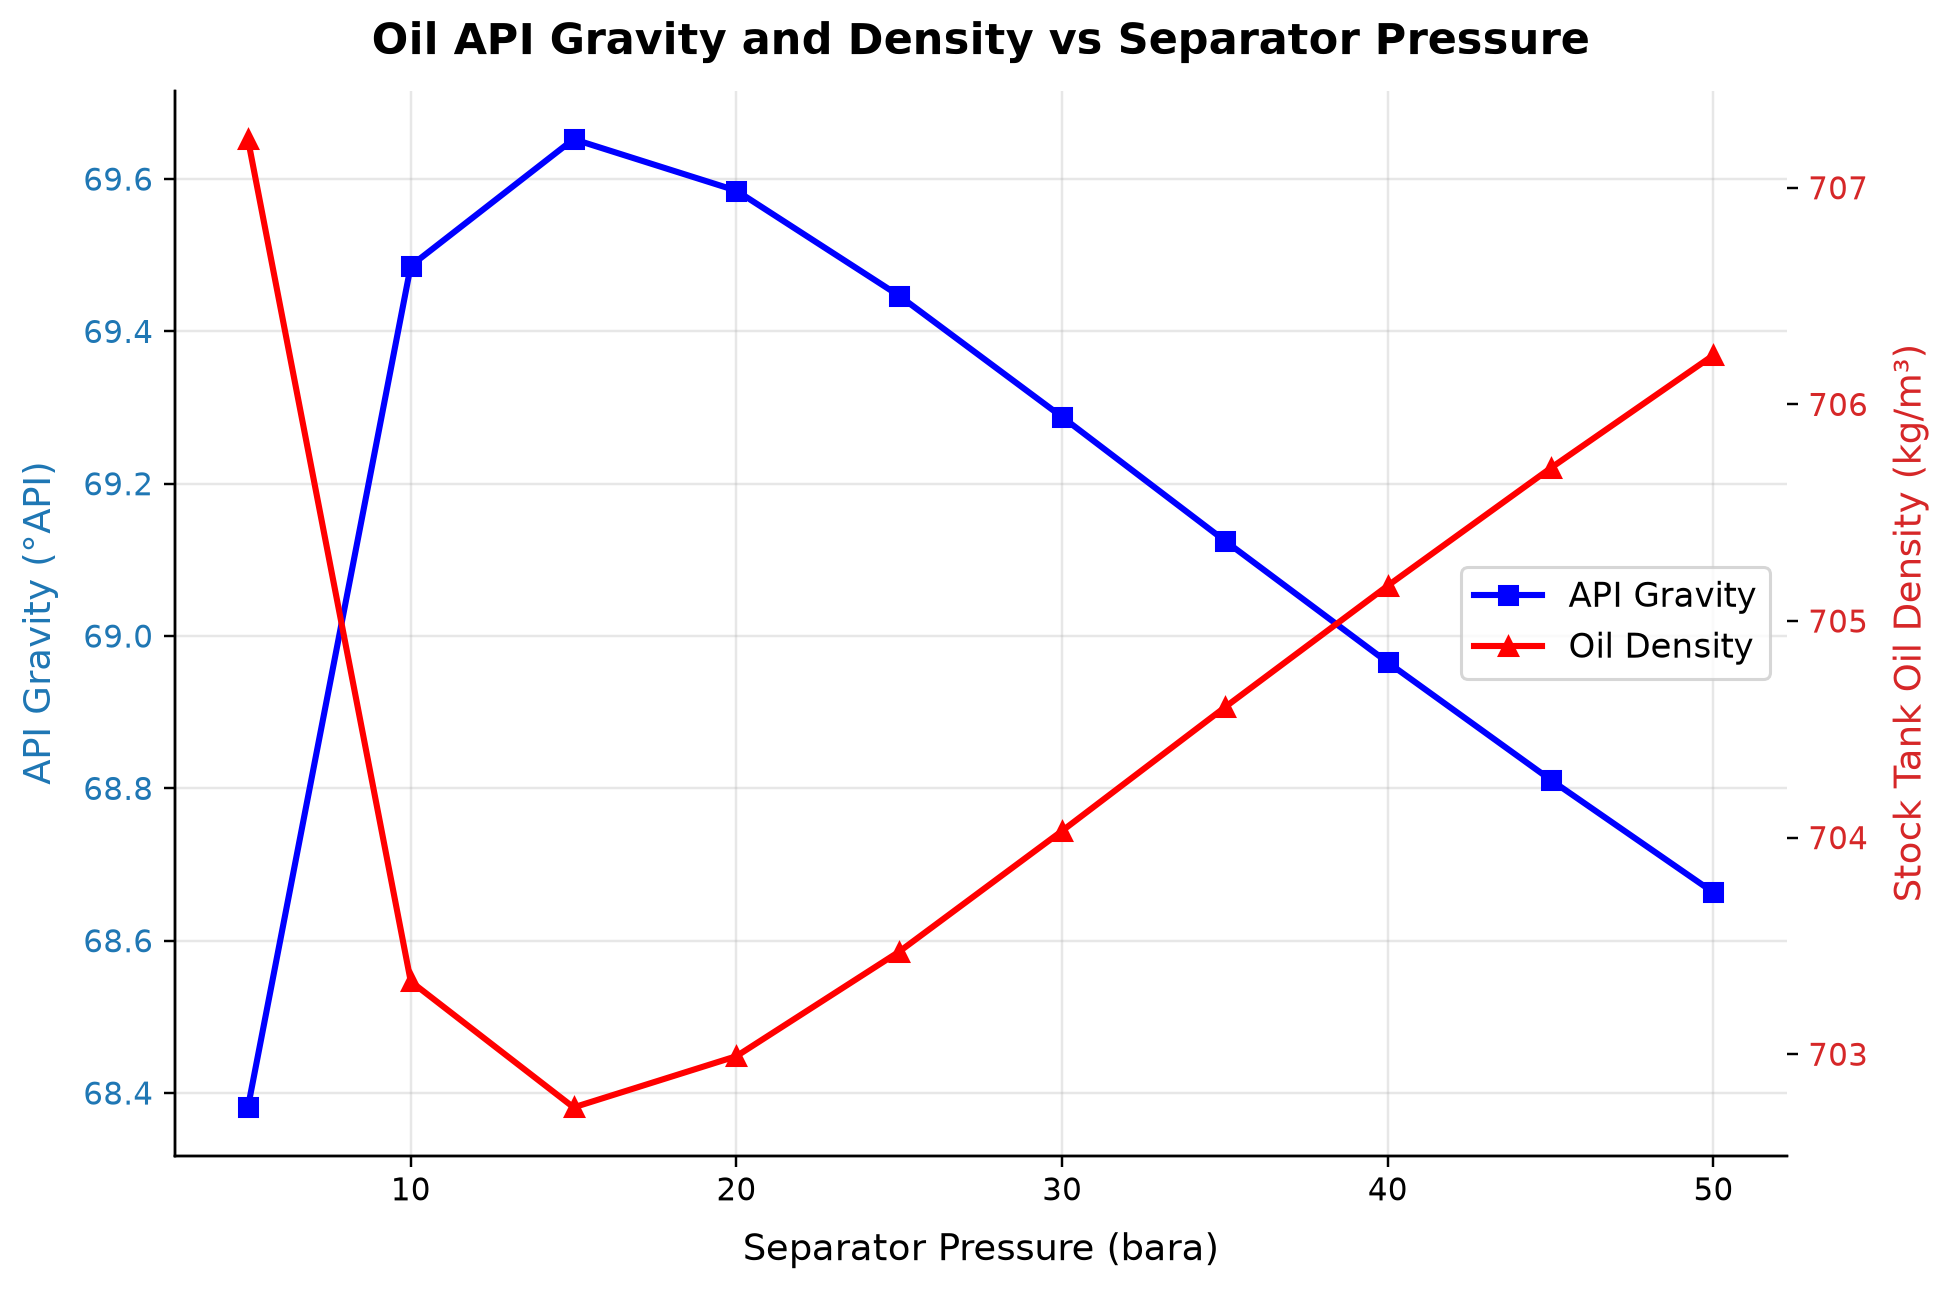

In [5]:
sep_pressures = np.arange(5, 55, 5)
api_gravities = []
oil_densities = []

for p in sep_pressures:
    # First stage separation
    fluid = create_oil_fluid(temp_C=60.0, press_bara=float(p))
    ops = ThermodynamicOperations(fluid)
    ops.TPflash()
    fluid.initProperties()

    # Get liquid from first separator
    if fluid.getNumberOfPhases() > 1:
        liquid = fluid.phaseToSystem("oil")
    else:
        liquid = fluid.clone()

    # Flash to stock tank conditions (1 atm, 15.6°C)
    liquid.setTemperature(288.7056)
    liquid.setPressure(1.01325)
    ops2 = ThermodynamicOperations(liquid)
    ops2.TPflash()
    liquid.initProperties()

    # Get oil density
    if liquid.hasPhaseType("oil"):
        rho = float(liquid.getPhase("oil").getDensity("kg/m3"))
    else:
        rho = float(liquid.getDensity("kg/m3"))

    sg = rho / 999.016  # SG relative to water
    api = 141.5 / sg - 131.5
    api_gravities.append(api)
    oil_densities.append(rho)

fig, ax1 = plt.subplots(figsize=(9, 6))
color1 = 'tab:blue'
ax1.plot(sep_pressures, api_gravities, 'b-s', linewidth=2, markersize=6, label='API Gravity')
ax1.set_xlabel('Separator Pressure (bara)', fontsize=12)
ax1.set_ylabel('API Gravity (°API)', fontsize=12, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.plot(sep_pressures, oil_densities, 'r-^', linewidth=2, markersize=6, label='Oil Density')
ax2.set_ylabel('Stock Tank Oil Density (kg/m³)', fontsize=12, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_title('Oil API Gravity and Density vs Separator Pressure', fontsize=14)
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig10_2_api_vs_pressure.png', dpi=220, bbox_inches='tight')
plt.show()
print(f"API range: {min(api_gravities):.1f} - {max(api_gravities):.1f} °API")

**Executed-figure discussion.** API Gravity spans 68.38–69.65 °API across the plotted cases. Oil Density: stock tank oil density spans 702.8–707.2 kg/m³ across the plotted cases.

Separator pressure changes which light components remain in the oil; its reference-temperature density changes accordingly. API gravity is meaningful only at its defined density reference basis, and changes in API alone do not quantify saleable oil recovery. Calculate the oil sample density at 60°F and compare gravity together with stabilized oil volume and vapor pressure.


**Discussion:** There is an optimal separator pressure that maximizes stock tank oil recovery (highest API gravity / lowest density at stock tank). At very low pressures, too much intermediate-weight material flashes off. At very high pressures, insufficient gas separation leads to excessive flash loss at the stock tank. The optimum is typically 5-15 bara for medium crudes.

## Figure 3: Multi-Stage Stabilization — Oil Quality vs Number of Stages

Comparing oil quality (API gravity) from 1-stage, 2-stage, and 3-stage separation trains.

1 stages: API = 66.6°, Density = 713.6 kg/m3
2 stages: API = 68.0°, Density = 708.4 kg/m3
3 stages: API = 68.5°, Density = 706.8 kg/m3
4 stages: API = 68.8°, Density = 705.8 kg/m3


ch10_oil_processing_figures.ipynb:cell12:85: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


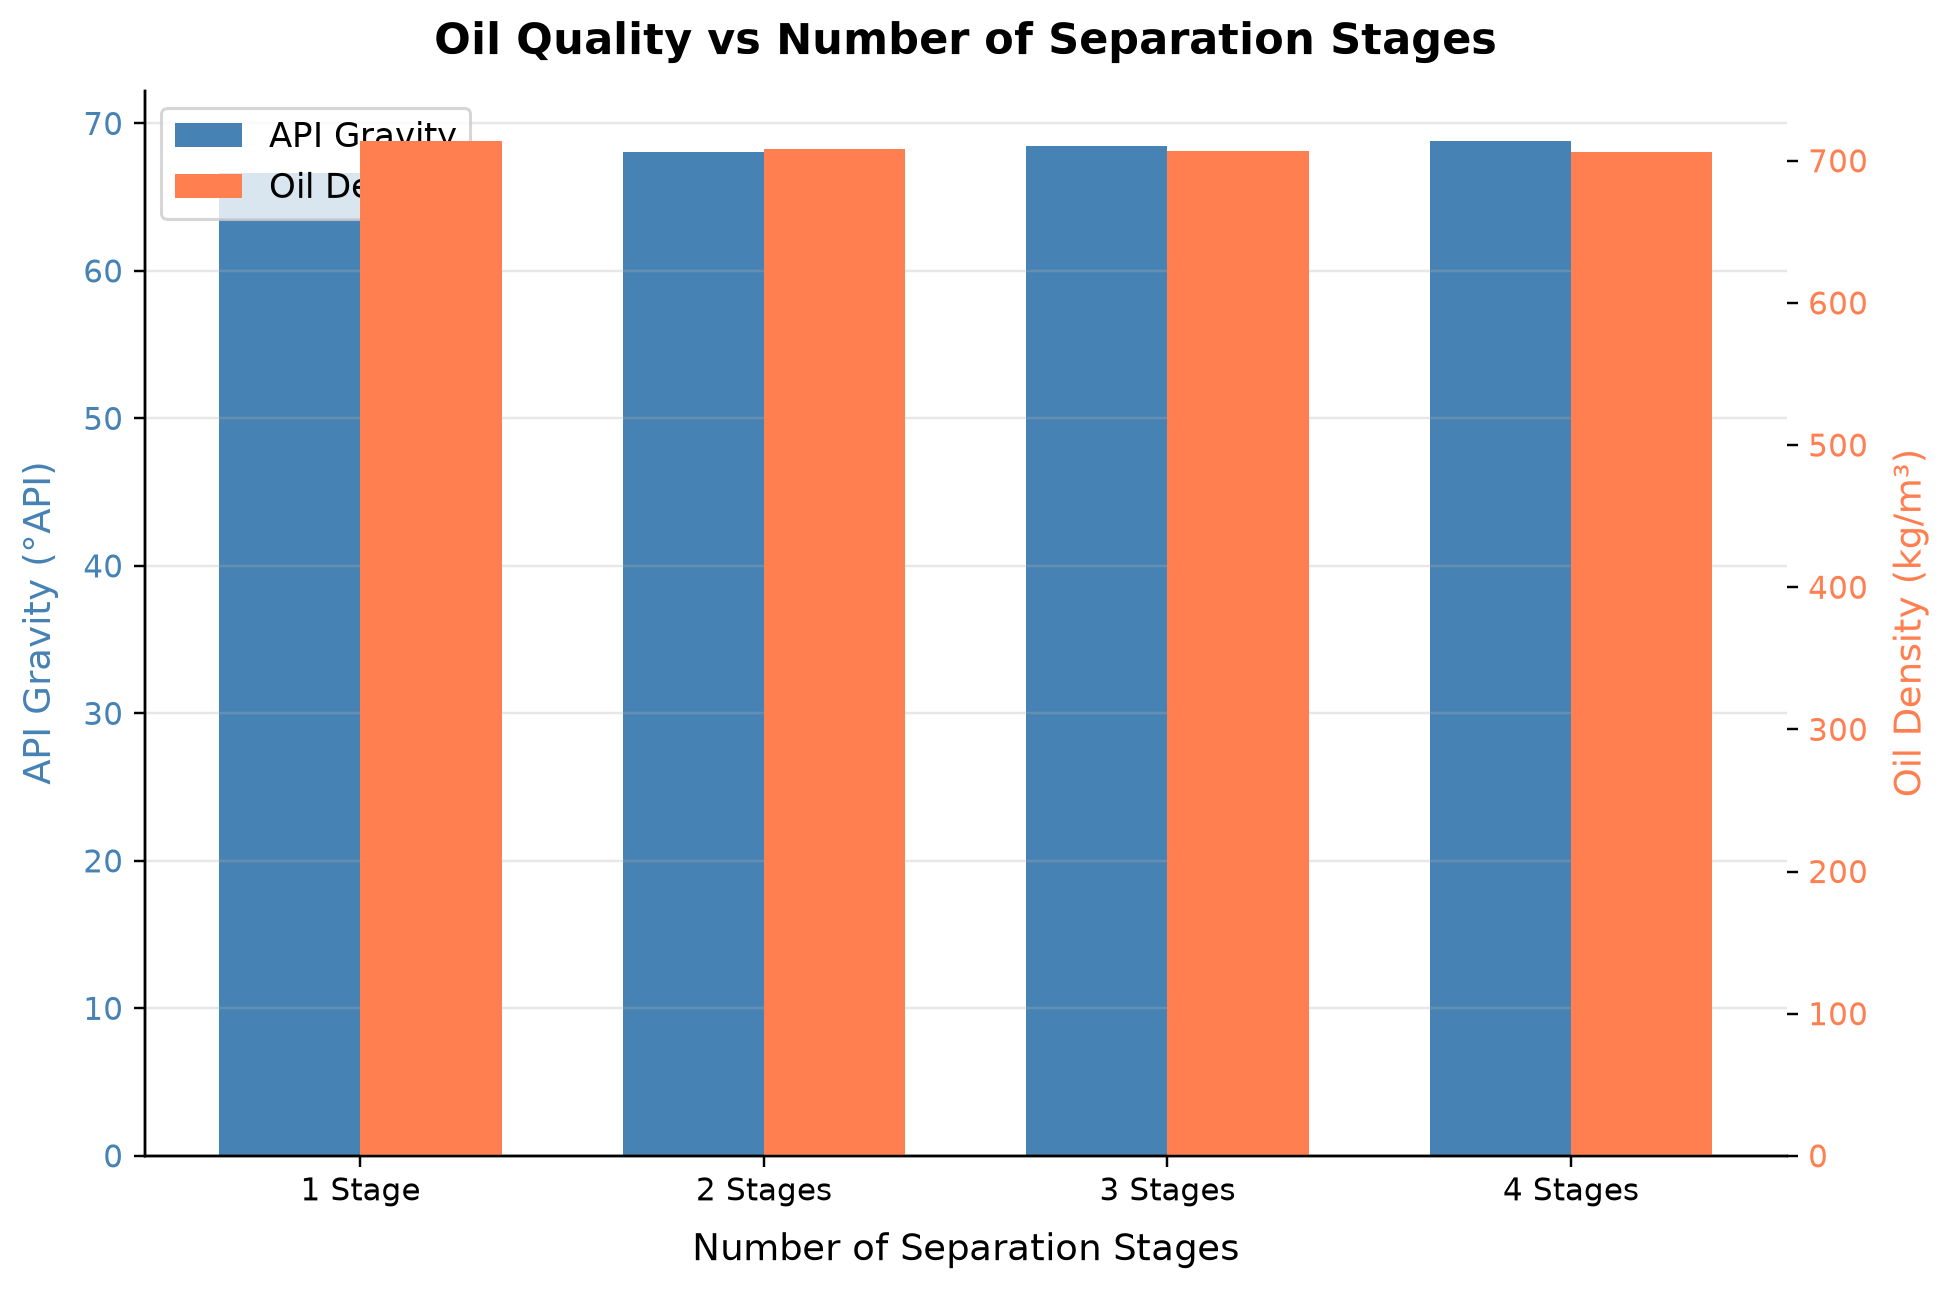

In [6]:
def simulate_multistage(n_stages, total_feed_pressure=50.0):
    """Simulate n-stage separation from feed pressure down to stock tank."""
    if n_stages == 1:
        stage_pressures = [1.01325]
    elif n_stages == 2:
        stage_pressures = [10.0, 1.01325]
    elif n_stages == 3:
        stage_pressures = [25.0, 5.0, 1.01325]
    elif n_stages == 4:
        stage_pressures = [30.0, 10.0, 3.0, 1.01325]
    else:
        stage_pressures = [1.01325]

    fluid = create_oil_fluid(temp_C=80.0, press_bara=total_feed_pressure)
    ops = ThermodynamicOperations(fluid)
    ops.TPflash()
    fluid.initProperties()

    current_liquid = fluid.phaseToSystem("oil") if fluid.getNumberOfPhases() > 1 else fluid.clone()

    total_gas_volume = 0.0
    for p_stage in stage_pressures:
        current_liquid.setTemperature(273.15 + 40.0)
        current_liquid.setPressure(p_stage)
        ops_s = ThermodynamicOperations(current_liquid)
        ops_s.TPflash()
        current_liquid.initProperties()

        if current_liquid.getNumberOfPhases() > 1 and current_liquid.hasPhaseType("gas"):
            gas_vol = float(current_liquid.getPhase("gas").getVolume("m3"))
            total_gas_volume += gas_vol
            current_liquid = current_liquid.phaseToSystem("oil")

    # Final stock tank flash
    current_liquid.setTemperature(288.7056)
    current_liquid.setPressure(1.01325)
    ops_f = ThermodynamicOperations(current_liquid)
    ops_f.TPflash()
    current_liquid.initProperties()

    if current_liquid.hasPhaseType("oil"):
        rho = float(current_liquid.getPhase("oil").getDensity("kg/m3"))
    else:
        rho = float(current_liquid.getDensity("kg/m3"))

    sg = rho / 999.016
    api = 141.5 / sg - 131.5
    return api, rho

stages_list = [1, 2, 3, 4]
api_results = []
density_results = []

for n in stages_list:
    api, rho = simulate_multistage(n)
    api_results.append(api)
    density_results.append(rho)
    print(f"{n} stages: API = {api:.1f}°, Density = {rho:.1f} kg/m3")

fig, ax1 = plt.subplots(figsize=(9, 6))
x = np.arange(len(stages_list))
width = 0.35

bars1 = ax1.bar(x - width/2, api_results, width, color='steelblue', label='API Gravity')
ax1.set_ylabel('API Gravity (°API)', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, density_results, width, color='coral', label='Oil Density')
ax2.set_ylabel('Oil Density (kg/m³)', fontsize=12, color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

ax1.set_xlabel('Number of Separation Stages', fontsize=12)
ax1.set_title('Oil Quality vs Number of Separation Stages', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels([f'{n} Stage{"s" if n > 1 else ""}' for n in stages_list])
ax1.grid(True, alpha=0.3, axis='y')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig10_3_multistage_oil_quality.png', dpi=220, bbox_inches='tight')
plt.show()

**Executed-figure discussion.** API Gravity spans 66.6–68.77 °API across the plotted cases. Oil Density spans 705.8–713.6 kg/m³ across the plotted cases.

Additional equilibrium separation stages alter the release of light components and the final liquid composition. Stage count alone does not determine oil quality or optimal recovery; stage pressures and heat input remain part of the specification. Compare alternatives at the same final oil-quality target and include the recompression and heating duties of the added stages.


**Discussion:** Multi-stage separation improves stock tank oil recovery by allowing lighter intermediates to remain in the liquid phase. Each additional stage reduces flash loss, but with diminishing returns. The jump from 1 to 2 stages typically gives the largest benefit, and 3-stage systems are standard in most offshore production facilities.

## Figure 4: Gas Shrinkage — Gas Released at Each Pressure Stage

We flash the feed oil at successively lower pressures and measure how much gas is released at each stage.

Total gas released: 31.6 mol% of original feed


ch10_oil_processing_figures.ipynb:cell15:60: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


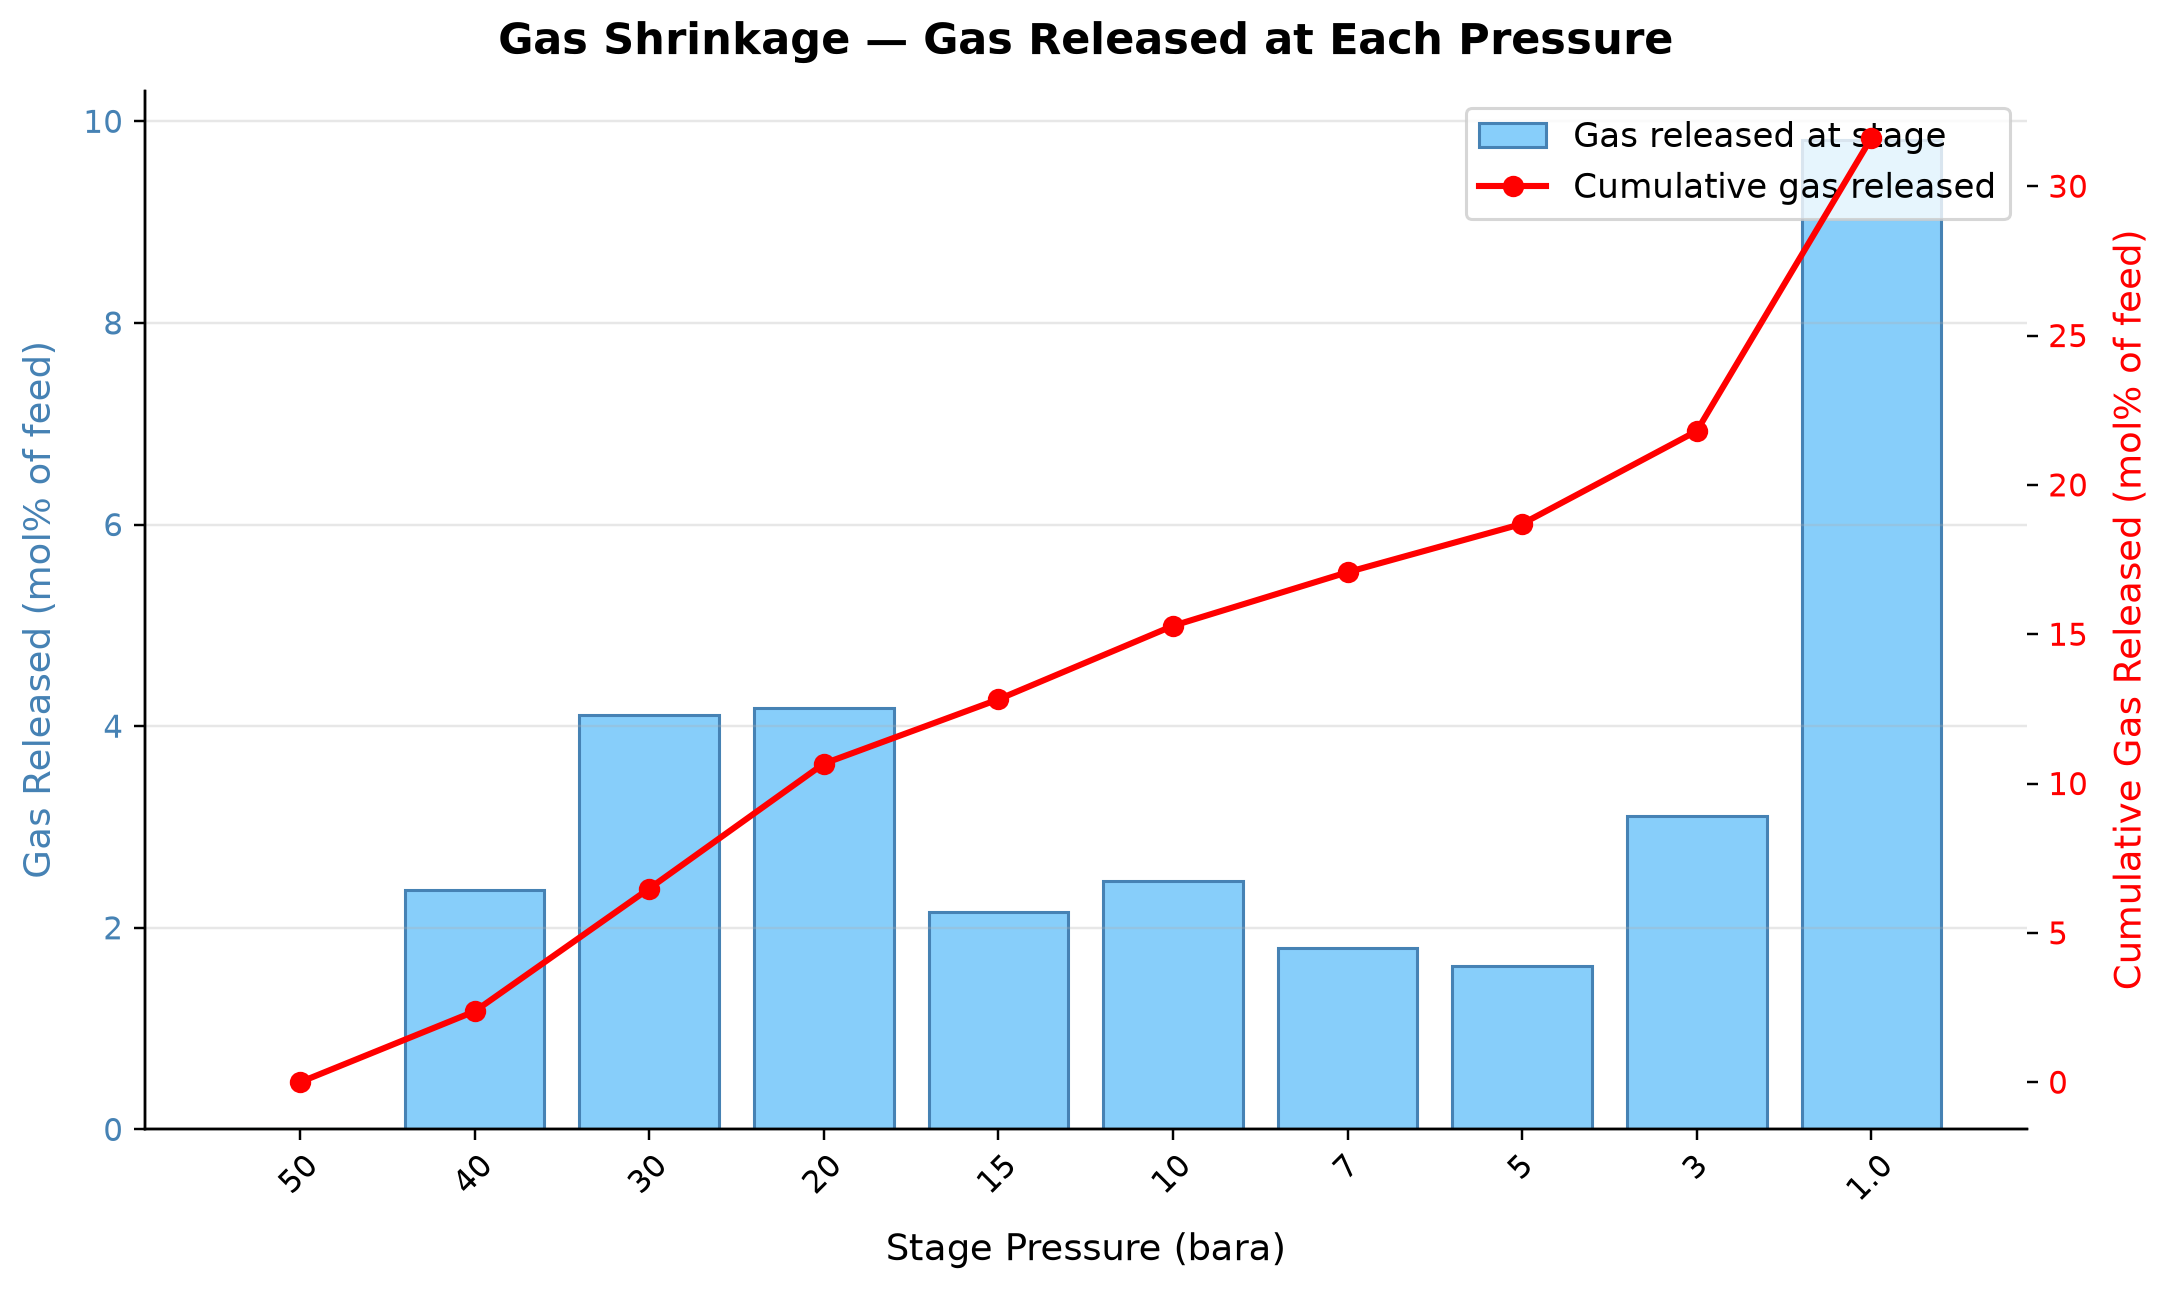

In [7]:
pressures = np.array([50, 40, 30, 20, 15, 10, 7, 5, 3, 1.01325])
gas_released_moles = []
cumulative_gas = []

fluid = create_oil_fluid(temp_C=80.0, press_bara=50.0)
ops = ThermodynamicOperations(fluid)
ops.TPflash()
fluid.initProperties()

total_moles = float(fluid.getTotalNumberOfMoles())
current_liquid = fluid.phaseToSystem("oil") if fluid.getNumberOfPhases() > 1 else fluid.clone()
cum_gas = 0.0

for p in pressures:
    current_liquid.setTemperature(273.15 + 60.0)
    current_liquid.setPressure(float(p))
    ops_s = ThermodynamicOperations(current_liquid)
    ops_s.TPflash()
    current_liquid.initProperties()

    if current_liquid.getNumberOfPhases() > 1 and current_liquid.hasPhaseType("gas"):
        gas_moles = float(current_liquid.getPhase("gas").getNumberOfMolesInPhase())
        gas_released_moles.append(gas_moles)
        cum_gas += gas_moles
        current_liquid = current_liquid.phaseToSystem("oil")
    else:
        gas_released_moles.append(0.0)

    cumulative_gas.append(cum_gas)

# Normalize to percentage of feed
gas_pct = [g / total_moles * 100 for g in gas_released_moles]
cum_pct = [g / total_moles * 100 for g in cumulative_gas]

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(range(len(pressures)), gas_pct, color='lightskyblue', edgecolor='steelblue',
        label='Gas released at stage')
ax1.set_ylabel('Gas Released (mol% of feed)', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(range(len(pressures)), cum_pct, 'r-o', linewidth=2, markersize=6,
         label='Cumulative gas released')
ax2.set_ylabel('Cumulative Gas Released (mol% of feed)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_xlabel('Stage Pressure (bara)', fontsize=12)
ax1.set_title('Gas Shrinkage — Gas Released at Each Pressure', fontsize=14)
ax1.set_xticks(range(len(pressures)))
ax1.set_xticklabels([f'{p:.0f}' if p > 2 else f'{p:.1f}' for p in pressures], rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig10_4_gas_shrinkage.png', dpi=220, bbox_inches='tight')
plt.show()
print(f"Total gas released: {cum_pct[-1]:.1f} mol% of original feed")

**Executed-figure discussion.** Gas released at stage: gas released spans 0–9.812 mol% of feed across the plotted cases. Cumulative gas released spans 0–31.61 mol% of feed across the plotted cases.

Gas liberation at successive pressure reductions changes the amount and composition of material retained as liquid. A pressure-sweep phase split is not the same experiment as differential liberation unless evolved gas is explicitly withdrawn at every step. State whether the material is recombined or depleted between points, and reconcile liberated gas and remaining oil with the overall material balance.


**Discussion:** Most gas liberation occurs at the first large pressure drop. As pressure decreases further, progressively less gas is released per unit pressure drop since the lighter components have already flashed off. This demonstrates why the first separator captures the majority of associated gas, and subsequent stages deal with smaller volumes of heavier gas.

## Summary

Key takeaways from oil processing and stabilization:

1. **Stabilizer temperature** directly controls the True Vapor Pressure at 37.8 °C of the product oil
2. **Separator pressure** has an optimum for maximizing stock tank oil recovery (API gravity)
3. **Multi-stage separation** significantly improves oil yield, with 2-3 stages being standard
4. **Gas shrinkage** is dominated by the first stage flash, with diminishing returns at lower pressures

These concepts are fundamental to topside process design and optimization of oil production facilities.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [8]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                            Figure  Panel                           Series                          Output / unit  Minimum  Maximum  Finite points  Missing points
    fig10_1_rvp_vs_temperature.png      1                          Curve 1  True Vapor Pressure at 37.8 °C (bara) 0.971027  2.21158             15               0
    fig10_1_rvp_vs_temperature.png      1 Illustrative TVP target (1 bara)  True Vapor Pressure at 37.8 °C (bara)        1        1              2               0
       fig10_2_api_vs_pressure.png      1                      API Gravity                     API Gravity (°API)  68.3811  69.6524             10               0
       fig10_2_api_vs_pressure.png      2                      Oil Density         Stock Tank Oil Density (kg/m³)  702.755  707.224             10               0
fig10_3_multistage_oil_quality.png      1                      API Gravity                     API Gravity (°API)  66.6036  68.7743              4               0
fig10_3_multistage_oil